In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import random
from collections import defaultdict, Counter

import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
base_dir = "drive/MyDrive/ProjectCapstone/DATA"

val_img_dir = os.path.join(base_dir, "val2017")
ann_file = os.path.join(base_dir, "captions_val2017.json")

In [ ]:
print(ann_file)

drive/MyDrive/ProjectCapstone/DATA/captions_val2017.json


In [ ]:
print("Annotation File Exists:", os.path.exists(ann_file))
print("Image folder Exists:", os.path.exists(val_img_dir))
print("Number of images:", len(os.listdir(val_img_dir)))

Annotation File Exists: True
Image folder Exists: True
Number of images: 5000


In [ ]:
with open(ann_file, "r") as f:
  coco = json.load(f)

type(coco)

dict

In [ ]:
images = coco["images"]
annotations = coco["annotations"]

In [ ]:
print("Number of images:", len(images))
print("Number of annotations:", len(annotations))
print("Keys:", coco.keys())

Number of images: 5000
Number of annotations: 25014
Keys: dict_keys(['info', 'licenses', 'images', 'annotations'])


In [ ]:
images[0]


{'license': 4,
 'file_name': '000000397133.jpg',
 'coco_url': 'http://images.cocodataset.org/val2017/000000397133.jpg',
 'height': 427,
 'width': 640,
 'date_captured': '2013-11-14 17:02:52',
 'flickr_url': 'http://farm7.staticflickr.com/6116/6255196340_da26cf2c9e_z.jpg',
 'id': 397133}

In [ ]:
annotations[0]

{'image_id': 179765,
 'id': 38,
 'caption': 'A black Honda motorcycle parked in front of a garage.'}

In [ ]:
from collections import defaultdict

#Mapping: image_id to list of captions
image_id_to_captions = defaultdict(list)

for ann in annotations:
    image_id_to_captions[ann["image_id"]].append(ann["caption"])

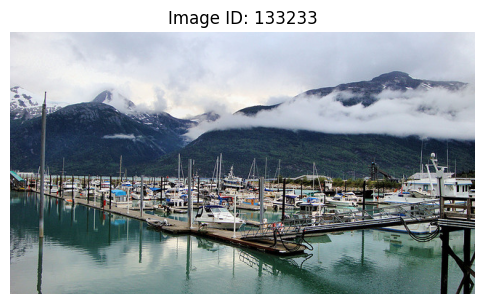

Captions:
1. A marina filled with boats floating in crystal blue water.
2. A harbor with boats is surrounded by mountains.
3. A large pier holding several boats overlooked by mountains.
4. A bunch of boats docked by the mountains
5. an overview image of a boat dock by mountains


In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Pick a random image
img = random.choice(images)

img_id = img["id"]
file_name = img["file_name"]

#Path to image
img_path = os.path.join(val_img_dir, file_name)

#Load and display image
image = Image.open(img_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Image ID: {img_id}")
plt.show()

#Print its captions
print("Captions:")
for i, cap in enumerate(image_id_to_captions[img_id], 1):
    print(f"{i}. {cap}")

In [ ]:
for i in range(5):
    img = images[i]
    print(img["width"], img["height"])

640 427
352 230
640 428
640 480
640 388


In [ ]:
#checking img mode

img = Image.open(img_path)

print(img.mode)   # before
img = img.convert("RGB")
print(img.mode)   # after

RGB
RGB
